# 00 — Thống kê suy luận: khi nào một chênh lệch là thật

Mọi bảng trong README của dự án đều có cột **p**, và biểu đồ có **khoảng tin cậy**.
Các con số đó quyết định kết luận: "giảm độ phân giải làm mất khoảng 2 điểm" là có thật,
còn với nf4 thì dữ liệu không phân biệt được với "không đổi". Notebook này xây toàn bộ công cụ đó
từ những thứ bạn đã biết — trung bình, phương sai, độ lệch chuẩn — và kiểm chứng từng
công thức bằng mô phỏng lẫn dữ liệu thật của dự án.

| Mục | Câu hỏi nó trả lời |
|---|---|
| 1. Ước lượng | 55,2% đo trên 1.920 câu nói gì về độ chính xác "thật"? |
| 2. Sai số chuẩn | Nếu đo lại trên một bộ câu hỏi khác, con số dao động bao nhiêu? |
| 3. Khoảng tin cậy | Khoảng nào nhiều khả năng chứa giá trị thật? |
| 4. Kiểm định và p-value | Chênh lệch giữa hai cấu hình có vượt quá mức ngẫu nhiên? |
| 5. McNemar | Vì sao so theo cặp mạnh hơn so hai con số rời? |
| 6. Lực kiểm định | Vì sao 100 hay 300 câu không đủ, mà phải cần cả 1.920? |
| 7. Bootstrap | Khoảng tin cậy cho những đại lượng không có công thức |
| 8. Độ lớn hiệu ứng | "Có ý nghĩa thống kê" khác "đáng kể" ở đâu? |

Các notebook sau (01 đến 07) đều dùng công cụ trong notebook này.

*Code in số thập phân bằng dấu chấm; phần chữ dùng dấu phẩy.*

In [1]:
import json, math, sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.metrics import wilson_interval, mcnemar

RESULTS = Path("../results")
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})

def load(name):
    return json.loads((RESULTS / name).read_text())

def per_sample(run, config):
    """sample_id -> list of 0/1 outcomes over the replicate rounds."""
    out = defaultdict(list)
    for r in run["records"]:
        if r["config"] == config:
            out[r["sample_id"]].append(int(r["correct"]))
    return dict(out)

confirm = load("gate2_confirm.json")          # all 1,920 ChartQA validation questions x 2 rounds
base = per_sample(confirm, "baseline")
e768 = per_sample(confirm, "edge768(edge=768)")
print("configs:", list(confirm["configs"]))
print("samples:", len(base), "| rounds per sample:", {len(v) for v in base.values()})

configs: ['baseline', 'edge768(edge=768)']
samples: 1920 | rounds per sample: {2}


## 1. Độ chính xác đo được chỉ là một ước lượng

Tập validation của ChartQA có 1.920 câu; dự án chấm trên cả 1.920 câu đó. Nhưng điều ta
thực sự muốn biết là độ chính xác trên **toàn bộ phân phối câu hỏi** kiểu ChartQA — gọi là
$p$ — và 1.920 câu chỉ là một **mẫu** rút từ phân phối đó. Tỉ lệ đúng đo được trên mẫu gọi
là $\hat p$. Hai con số này khác nhau, và
toàn bộ thống kê suy luận là việc định lượng *khác bao nhiêu*.

Mô hình hoá: câu thứ $i$ cho kết quả $X_i = 1$ nếu đúng, $0$ nếu sai. Vì câu hỏi được
rút ngẫu nhiên, $X_i$ là một **biến Bernoulli**: bằng 1 với xác suất $p$, bằng 0 với
xác suất $1-p$.

$$\mathbb{E}[X_i] = 1\cdot p + 0\cdot(1-p) = p,\qquad
\operatorname{Var}(X_i) = \mathbb{E}[X_i^2] - \mathbb{E}[X_i]^2 = p - p^2 = p(1-p)$$

(Bước giữa dùng $X_i^2 = X_i$, vì $0^2=0$ và $1^2=1$.)

**Ký hiệu mới**
- $p$: độ chính xác thật (không quan sát được) · $\hat p$: độ chính xác đo trên mẫu
- $n$: số mẫu · $k$: số câu đúng, nên $\hat p = k/n$
- $X_i$: kết quả câu thứ $i$ (0 hoặc 1) · $\mathbb{E}$: kỳ vọng (trung bình lý thuyết)

**Một chi tiết của dữ liệu:** mỗi câu được chạy 2 vòng. Mô hình giải mã tham lam
(greedy, không lấy mẫu ngẫu nhiên), nên hai vòng lẽ ra cho cùng kết quả. Kiểm tra:

In [2]:
agree = sum(len(set(v)) == 1 for v in base.values())
print(f"baseline: {agree}/{len(base)} samples give the same answer in both rounds")

x_base = np.array([v[0] for _, v in sorted(base.items())])
x_e768 = np.array([e768[s][0] for s in sorted(base)])
n = len(x_base)
print(f"n = {n}, k = {x_base.sum()}, p_hat = {x_base.mean():.4f}")

baseline: 1920/1920 samples give the same answer in both rounds
n = 1920, k = 1060, p_hat = 0.5521


Hai vòng khớp hoàn toàn, nên từ đây mỗi câu được tính là **một** quan sát
(không phải hai). Đây là điểm quan trọng: lặp lại vòng đo giúp đo **thời gian** chính
xác hơn, nhưng **không** thêm thông tin về **độ chính xác** — câu nào sai thì sai cả hai
lần. Số mẫu thật cho độ chính xác là $n = 1.920$, không phải 3.840.

## 2. Sai số chuẩn: con số dao động bao nhiêu

$\hat p$ là trung bình của $n$ biến độc lập. Phương sai của một tổng các biến độc lập
bằng tổng các phương sai, và nhân một biến với hằng số $c$ thì phương sai nhân $c^2$:

$$\operatorname{Var}(\hat p) = \operatorname{Var}\Big(\frac1n\sum_{i=1}^n X_i\Big)
= \frac{1}{n^2}\cdot n\,p(1-p) = \frac{p(1-p)}{n}$$

Căn bậc hai của nó gọi là **sai số chuẩn** (standard error, SE) — độ lệch chuẩn của
*chính con số ước lượng*, nếu ta lặp lại toàn bộ thí nghiệm nhiều lần:

$$\mathrm{SE}(\hat p) = \sqrt{\frac{p(1-p)}{n}}$$

**Lưu ý:** độ lệch chuẩn mô tả độ phân tán của *từng quan sát*; sai số chuẩn mô tả độ
phân tán của *trung bình*. Nó giảm theo $\sqrt n$: muốn sai số giảm một nửa, cần gấp
**bốn** lần số mẫu.

Với dự án: $\hat p = 0{,}552$, $n = 1.920$ cho
$\mathrm{SE} = \sqrt{0{,}552 \times 0{,}448 / 1.920} \approx 0{,}0113$, tức **±1,13 điểm**
cho mỗi độ lệch chuẩn. (Với 300 câu, SE sẽ lớn gấp $\sqrt{1.920/300} \approx 2{,}5$ lần.)
Kiểm chứng bằng mô phỏng: giả sử $p$ thật đúng bằng 0,552, lặp lại "chấm 1.920 câu" 100.000
lần và xem $\hat p$ phân tán ra sao.

SE by formula    : 0.0113
SE by simulation : 0.0113


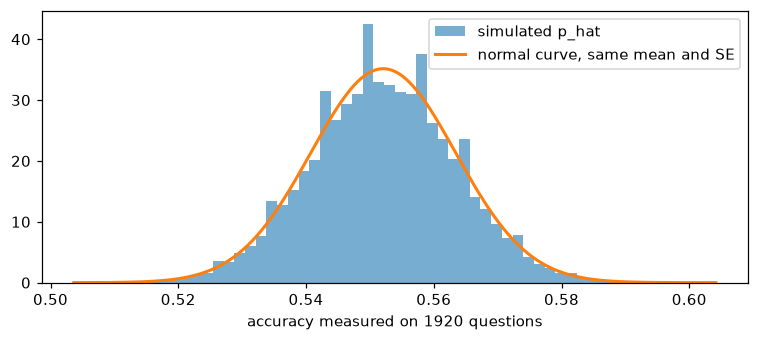

In [3]:
p_true = x_base.mean()
se_formula = math.sqrt(p_true * (1 - p_true) / n)

sims = rng.binomial(n, p_true, size=100_000) / n      # 100k repeats of "score n questions"
print(f"SE by formula    : {se_formula:.4f}")
print(f"SE by simulation : {sims.std():.4f}")

xs = np.linspace(sims.min(), sims.max(), 300)
normal_pdf = np.exp(-(xs - p_true) ** 2 / (2 * se_formula ** 2)) / (se_formula * math.sqrt(2 * math.pi))
plt.hist(sims, bins=60, density=True, alpha=0.6, label="simulated p_hat")
plt.plot(xs, normal_pdf, lw=2, label="normal curve, same mean and SE")
plt.xlabel(f"accuracy measured on {n} questions"); plt.legend(); plt.tight_layout(); plt.show()

Hai con số khớp, và biểu đồ cho thấy một điều nữa: phân phối của $\hat p$ có dạng
**hình chuông**. Đó là **định lý giới hạn trung tâm** (central limit theorem): trung bình
của nhiều biến độc lập có phương sai hữu hạn thì xấp xỉ **phân phối chuẩn**, bất kể
từng biến phân phối ra sao (ở đây từng biến chỉ nhận 0 hoặc 1). Xấp xỉ này tốt khi
$n p$ và $n(1-p)$ đều đủ lớn (quy tắc thường dùng: cả hai trên khoảng 10).

Phân phối của một ước lượng qua các lần lặp giả định như vậy gọi là **phân phối lấy mẫu**
(sampling distribution). Mọi công cụ còn lại trong notebook đều là cách suy luận về nó
khi ta chỉ có **một** lần đo.

## 3. Khoảng tin cậy

### 3.1. Khoảng Wald — cách hiển nhiên

Với phân phối chuẩn, 95% khối lượng nằm trong khoảng $\pm 1{,}96$ độ lệch chuẩn quanh
trung bình. Con số 1,96 là $z_{0{,}975}$ — giá trị $z$ sao cho $\Phi(z) = 0{,}975$,
với $\Phi$ là hàm phân phối tích luỹ của phân phối chuẩn tắc:

$$\Phi(z) = P(Z \le z) = \tfrac12\Big(1 + \operatorname{erf}\big(z/\sqrt2\big)\Big)$$

Vậy $P\big(|\hat p - p| \le 1{,}96\,\mathrm{SE}\big) \approx 0{,}95$. Đảo lại, và thay
$p$ chưa biết trong SE bằng $\hat p$, ta được **khoảng Wald**:

$$\hat p \pm z\sqrt{\frac{\hat p(1-\hat p)}{n}}$$

**Ký hiệu mới**
- $Z$: biến chuẩn tắc (trung bình 0, độ lệch chuẩn 1) · $\Phi$: hàm tích luỹ của nó
- $z$: số độ lệch chuẩn tương ứng mức tin cậy (1,96 cho 95%)
- $\operatorname{erf}$: hàm lỗi Gauss, có sẵn trong `math.erf`

**"95%" nghĩa là gì — và không nghĩa là gì.** Nó **không** có nghĩa "có 95% xác suất
$p$ nằm trong khoảng này": $p$ là một hằng số, hoặc nằm trong hoặc không. Nó nghĩa là:
**nếu lặp lại toàn bộ thí nghiệm nhiều lần, thì 95% số khoảng được dựng ra sẽ chứa $p$.**
Con số 95% là tính chất của *quy trình*, gọi là **độ phủ** (coverage). Kiểm chứng:

In [4]:
def phi(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

def z_for(conf):
    """Inverse of phi by bisection: the z with phi(z) = (1 + conf) / 2."""
    lo, hi, target = 0.0, 10.0, (1 + conf) / 2
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if phi(mid) < target else (lo, mid)
    return lo

Z = z_for(0.95)
print(f"z for 95% = {Z:.4f}")

def wald(k, n, z=Z):
    p = k / n
    h = z * math.sqrt(p * (1 - p) / n)
    return p - h, p + h

def coverage(interval, p, n, trials=20_000):
    ks = rng.binomial(n, p, size=trials)
    hits = 0
    for k in ks:
        lo, hi = interval(k, n)
        hits += lo <= p <= hi
    return hits / trials

print(f"Wald coverage, p = {p_true:.3f}, n = {n}: {coverage(wald, p_true, n):.3f}")

z for 95% = 1.9600
Wald coverage, p = 0.552, n = 1920: 0.948


Với $n = 1.920$ và $p$ ở giữa khoảng, Wald đạt đúng độ phủ đã hứa. Nhưng dự án có những
dòng chỉ 40 mẫu, và những cấu hình có độ chính xác thấp. Xem Wald cư xử thế nào ở đó:

In [5]:
print(f"{'n':>4} {'p':>5} | {'Wald':>6} {'Wilson':>7}")
for n_, p_ in [(n, round(p_true, 3)), (40, 0.55), (40, 0.25), (40, 0.1), (20, 0.05)]:
    print(f"{n_:>4} {p_:>5} | {coverage(wald, p_, n_):6.3f} "
          f"{coverage(lambda k, m: wilson_interval(k, m), p_, n_):7.3f}")

   n     p |   Wald  Wilson
1920 0.552 |  0.951   0.949
  40  0.55 |  0.940   0.963
  40  0.25 |  0.945   0.958


  40   0.1 |  0.916   0.944
  20  0.05 |  0.640   0.924


Độ phủ của Wald tụt khi $n$ nhỏ và $p$ gần 0: với 40 mẫu và $p = 0{,}1$ còn khoảng 91%,
với 20 mẫu và $p = 0{,}05$ chỉ còn khoảng **64%** — một "khoảng 95%" mà sai gần một nửa
số lần. Nguyên nhân: Wald thay $p$ trong công thức SE bằng
$\hat p$. Khi $\hat p$ gần 0, SE ước lượng ra gần 0, khoảng co lại quá mức; trường
hợp cực đoan $k = 0$ cho khoảng $[0, 0]$ — tuyên bố chắc chắn tuyệt đối từ vài chục mẫu.

### 3.2. Khoảng Wilson — giữ nguyên $p$ trong công thức

Wilson không thay $p$ bằng $\hat p$. Nó hỏi thẳng: **những giá trị $p$ nào khiến
$\hat p$ đo được không quá xa?** Tức là giải bất phương trình theo $p$:

$$(\hat p - p)^2 \le z^2\,\frac{p(1-p)}{n}$$

Khai triển thành bậc hai theo $p$:
$\;\big(1 + \tfrac{z^2}{n}\big)p^2 - \big(2\hat p + \tfrac{z^2}{n}\big)p + \hat p^2 \le 0.$
Hai nghiệm của phương trình bậc hai này là hai đầu khoảng:

$$\frac{\hat p + \dfrac{z^2}{2n}}{1 + \dfrac{z^2}{n}}
\;\pm\;
\frac{z}{1 + \dfrac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}$$

Hai điểm đáng chú ý:
- **Tâm khoảng bị kéo về 0,5** (số hạng $z^2/2n$): với ít mẫu, ta không tin hẳn vào
  $\hat p$ cực đoan.
- **Khi $n$ lớn**, các số hạng $z^2/n$ tiến về 0 và Wilson trùng với Wald.

Đây chính là hàm `wilson_interval` trong `bench/metrics.py`. Bảng ở trên cho thấy
Wilson giữ độ phủ gần 95% ở mọi trường hợp. Áp vào các dòng kết quả của dự án:

In [6]:
k_b, k_e = int(x_base.sum()), int(x_e768.sum())
for name, k, m in [(f"baseline, {n} samples", k_b, n), (f"edge768, {n} samples", k_e, n)]:
    lo, hi = wilson_interval(k, m)
    print(f"{name:<24} {100*k/m:5.1f}%  Wilson [{100*lo:4.1f}, {100*hi:4.1f}]  width {100*(hi-lo):4.1f} pts")

baseline, 1920 samples    55.2%  Wilson [53.0, 57.4]  width  4.4 pts
edge768, 1920 samples     53.0%  Wilson [50.8, 55.2]  width  4.5 pts


Với 1.920 câu, khoảng chỉ rộng khoảng 4,5 điểm. Giờ đến một lần quét nhỏ hơn: lần quét đòn bẩy
đầu tiên của dự án, 40 câu × 3 vòng (nay lưu ở `results/history/`) — và một lỗi thật mà
notebook này tìm ra trong code của dự án lúc đó.

In [7]:
sweep = load("history/gate2_sweep_layout_tokens_deleted.json")   # the old 40 x 3 sweep
print(f"{'config':<22} {'acc':>6} | {'CI stored by harness':>22} | {'Wilson with n = 40':>20}")
for cfg in ["baseline", "keep0.25:uniform(keep=0.25,uniform)", "keep0.25:random(keep=0.25,random)"]:
    ps = per_sample(sweep, cfg)
    k_all = sum(sum(v) for v in ps.values()); n_all = sum(len(v) for v in ps.values())
    stored = sweep["configs"][cfg]["accuracy_ci95"]
    lo, hi = wilson_interval(round(k_all / 3), len(ps))       # one observation per question
    print(f"{cfg.split('(')[0]:<22} {100*k_all/n_all:5.1f}% | "
          f"[{100*stored[0]:4.1f}, {100*stored[1]:4.1f}] width {100*(stored[1]-stored[0]):4.1f} | "
          f"[{100*lo:4.1f}, {100*hi:4.1f}] width {100*(hi-lo):4.1f}")

config                    acc |   CI stored by harness |   Wilson with n = 40
baseline                55.0% | [46.1, 63.6] width 17.5 | [39.8, 69.3] width 29.5
keep0.25:uniform        30.0% | [22.5, 38.7] width 16.2 | [18.1, 45.4] width 27.4
keep0.25:random         31.7% | [24.0, 40.4] width 16.4 | [20.1, 48.0] width 27.9


**Lỗi: vòng lặp bị đếm như mẫu mới.** `bench/harness.py` khi đó gọi `wilson_interval(k, n)` với
$n$ là **số bản ghi** — 40 câu × 3 vòng = 120. Nhưng như mục 1 đã thấy, các vòng của
một cấu hình tất định cho *cùng* đáp án, nên 120 bản ghi chỉ chứa thông tin của 40 quan
sát. Vì SE tỉ lệ với $1/\sqrt n$, khoảng tin cậy bị hẹp đi khoảng $\sqrt 3 \approx 1{,}7$
lần: khoảng đúng rộng gần **30 điểm**, không phải 17. Các thanh sai số trên biểu đồ trong
README lúc đó vì thế **trông chắc chắn hơn thực tế**. Lỗi đã được sửa: harness giờ dùng
`accuracy_ci` trong `bench/metrics.py`, tính mỗi câu hỏi là một quan sát.

Quy tắc tổng quát: **số quan sát độc lập mới là $n$**, không phải số dòng trong file.
Lặp lại một phép đo tất định không tạo thêm thông tin.

(Riêng cấu hình chọn token **ngẫu nhiên**, mỗi vòng chọn một tập token khác, nên các
vòng *không* trùng nhau hoàn toàn — nhưng chúng vẫn dùng chung 40 câu hỏi, nên số quan
sát độc lập vẫn gần 40 hơn 120.)

Với khoảng đúng, "cách đều" và "ngẫu nhiên" chồng lên nhau gần như hoàn toàn: 40 câu là
quá ít để phân biệt chúng. Đó là lý do lần quét hiện tại của dự án dùng 100 câu cho mọi cấu
hình (notebook 01 kể tiếp câu chuyện của lần quét cũ này).

## 4. Kiểm định giả thuyết và p-value

Câu hỏi của dự án thường có dạng: cấu hình B (cạnh 768) có **thật sự** kém cấu hình A
(bản gốc) không, hay chênh lệch 2,2 điểm chỉ là may rủi của việc chọn mẫu?

Kiểm định giả thuyết trả lời theo lối **phản chứng**:

1. **Giả thuyết không** $H_0$: hai cấu hình có cùng độ chính xác thật.
2. Chọn một **thống kê kiểm định** — một con số tính từ dữ liệu, càng lớn thì càng
   trái với $H_0$.
3. **p-value** = xác suất, *nếu $H_0$ đúng*, thấy thống kê kiểm định **ít nhất cực đoan
   bằng** giá trị đã quan sát.
4. Nếu p-value nhỏ hơn ngưỡng $\alpha$ (thường 0,05), bác bỏ $H_0$.

$$\text{p-value} = P\big(\,T \ge t_{\text{quan sát}} \;\big|\; H_0\,\big)$$

**Ký hiệu mới**
- $H_0$: giả thuyết không · $T$: thống kê kiểm định · $\alpha$: ngưỡng bác bỏ
- $P(\cdot \mid H_0)$: xác suất tính trong thế giới giả định $H_0$ đúng

**Hai loại sai lầm:**

| | $H_0$ thật sự đúng | $H_0$ thật sự sai |
|---|---|---|
| Bác bỏ $H_0$ | **sai lầm loại I** (xác suất $\alpha$) | đúng — xác suất này là **lực** (power) |
| Không bác bỏ | đúng | **sai lầm loại II** (xác suất $\beta$, lực $= 1-\beta$) |

**Ba cách hiểu sai p-value thường gặp:**
- p-value **không** phải xác suất $H_0$ đúng. Nó được tính *với giả định* $H_0$ đúng.
- p-value **không** đo độ lớn hiệu ứng: chênh lệch nhỏ với rất nhiều mẫu vẫn cho p rất
  nhỏ (mục 8).
- p-value lớn **không** chứng minh $H_0$: có thể chỉ là thiếu mẫu (mục 6).

### 4.1. Cách thứ nhất: coi hai nhóm là độc lập

Cách quen thuộc nhất là so hai tỉ lệ như thể chúng đến từ hai nhóm câu hỏi khác nhau.
Dưới $H_0$, hai nhóm có chung tỉ lệ $\bar p$ (ước lượng bằng tỉ lệ gộp), và hiệu hai
tỉ lệ có sai số chuẩn $\sqrt{\bar p(1-\bar p)(1/n_A + 1/n_B)}$ — cộng phương sai của
hai ước lượng độc lập. Thống kê kiểm định:

$$z = \frac{\hat p_A - \hat p_B}{\sqrt{\bar p(1-\bar p)\left(\frac{1}{n_A}+\frac{1}{n_B}\right)}},
\qquad \text{p-value hai phía} = 2\big(1-\Phi(|z|)\big)$$

"Hai phía" vì trước khi đo, ta không giả định B kém hơn — B tốt hơn *hoặc* kém hơn đều
tính là cực đoan.

In [8]:
pA, pB = x_base.mean(), x_e768.mean()
p_pool = (x_base.sum() + x_e768.sum()) / (2 * n)
z = (pA - pB) / math.sqrt(p_pool * (1 - p_pool) * (2 / n))
p_unpaired = 2 * (1 - phi(abs(z)))
print(f"baseline {100*pA:.1f}%  vs  edge768 {100*pB:.1f}%  -> diff {100*(pA-pB):.1f} pts")
print(f"unpaired z = {z:.2f}, p = {p_unpaired:.4f}")

baseline 55.2%  vs  edge768 53.0%  -> diff 2.2 pts
unpaired z = 1.36, p = 0.1738


Theo cách này, p khoảng 0,17 — **không** vượt ngưỡng 0,05. Nhưng README ghi p = 0,011 cho
cùng dữ liệu. Chênh lệch gấp khoảng 16 lần đến từ việc cách trên đã
**bỏ phí** một thông tin quan trọng: hai cấu hình được chấm trên **cùng** 300 câu hỏi.

## 5. Thiết kế theo cặp và kiểm định McNemar

Câu hỏi trong ChartQA có độ khó rất khác nhau. Câu dễ thì cả hai cấu hình cùng đúng,
câu khó thì cùng sai. Phép so độc lập coi toàn bộ sự khác nhau về độ khó đó là nhiễu,
nên SE của nó lớn. Nếu hai cấu hình chạy trên **cùng** câu hỏi, ta có thể so **từng
câu một**, và độ khó của câu tự triệt tiêu.

Xếp 300 câu vào bảng 2×2:

| | B đúng | B sai |
|---|---|---|
| **A đúng** | cùng đúng | $b$ — chỉ A đúng |
| **A sai** | $c$ — chỉ B đúng | cùng sai |

Các câu **cùng đúng** hoặc **cùng sai** không nói gì về việc cấu hình nào tốt hơn. Chỉ
các **cặp bất đồng** ($b$ và $c$) mang thông tin.

Dưới $H_0$ (hai cấu hình ngang nhau), mỗi cặp bất đồng có khả năng như nhau rơi vào
phía "chỉ A đúng" hay "chỉ B đúng" — như tung một đồng xu cân. Vậy trong $d = b + c$
cặp bất đồng, $b$ tuân theo **phân phối nhị thức** $\mathrm{Binomial}(d, \tfrac12)$:

$$P(b = i \mid H_0) = \binom{d}{i}\Big(\frac12\Big)^{d}$$

p-value hai phía là xác suất thấy một phía lệch **ít nhất bằng** quan sát:

$$\text{p} = \min\Big(1,\; 2\sum_{i=0}^{\min(b,c)} \binom{d}{i}\Big(\frac12\Big)^{d}\Big)$$

**Ký hiệu mới**
- $b, c$: số cặp bất đồng mỗi phía · $d = b + c$
- $\binom{d}{i}$: số cách chọn $i$ phần tử từ $d$ (`math.comb`)

Đây là **kiểm định McNemar dạng chính xác** — "chính xác" vì dùng thẳng phân phối
nhị thức thay vì xấp xỉ chuẩn. Tính tay trên dữ liệu:

In [9]:
both    = int(((x_base == 1) & (x_e768 == 1)).sum())
only_a  = int(((x_base == 1) & (x_e768 == 0)).sum())
only_b  = int(((x_base == 0) & (x_e768 == 1)).sum())
neither = int(((x_base == 0) & (x_e768 == 0)).sum())
print(f"both right {both} | only baseline {only_a} | only edge768 {only_b} | both wrong {neither}")

d = only_a + only_b
p_hand = min(1.0, 2 * sum(math.comb(d, i) for i in range(min(only_a, only_b) + 1)) / 2 ** d)
print(f"McNemar by hand     : p = {p_hand:.4f}")
print(f"bench.metrics.mcnemar: p = {mcnemar(only_a, only_b):.4f}")

both right 910 | only baseline 150 | only edge768 108 | both wrong 752
McNemar by hand     : p = 0.0106
bench.metrics.mcnemar: p = 0.0106


Chỉ **258 trong 1.920 câu** mang thông tin so sánh, và 150 trên 258 nghiêng về bản gốc.
Nếu hai cấu hình ngang nhau, một đồng xu cân tung 258 lần mà ra 150 mặt ngửa hoặc nhiều
hơn (hay 108 hoặc ít hơn) chỉ xảy ra khoảng 1 lần trong 100.

**Kiểm chứng không cần công thức — kiểm định hoán vị.** Nếu $H_0$ đúng thì nhãn "A"
và "B" trong mỗi cặp có thể đổi chỗ cho nhau mà không thay đổi gì. Vậy: tráo nhãn ngẫu
nhiên trong từng cặp hàng trăm nghìn lần, đếm xem bao nhiêu lần chênh lệch ngẫu nhiên
lớn bằng chênh lệch thật.

In [10]:
diff_obs = abs(only_a - only_b)
flips = rng.integers(0, 2, size=(200_000, d))          # each discordant pair: keep or swap
b_sim = flips.sum(axis=1)
p_perm = np.mean(np.abs(b_sim - (d - b_sim)) >= diff_obs)
print(f"permutation test: p = {p_perm:.4f}   (exact McNemar: {p_hand:.4f})")

permutation test: p = 0.0103   (exact McNemar: 0.0106)


Mô phỏng thuần tuý cho cùng kết quả — công thức nhị thức chỉ là cách tính nhanh của
phép tráo nhãn này.

**Vì sao thiết kế theo cặp mạnh hơn:** phép so độc lập ở mục 4.1 phải "gánh" toàn bộ
dao động do câu dễ câu khó; McNemar loại bỏ phần đó bằng cách chỉ nhìn cặp bất đồng.
Cùng dữ liệu, p giảm từ khoảng 0,17 xuống 0,011.

### 5.1. Cùng ý tưởng cho thời gian: kiểm định dấu

Với độ trễ, mỗi câu có một cặp số đo (A, B). Hỏi: trong bao nhiêu câu B nhanh hơn A?
Dưới $H_0$ "hai cấu hình nhanh như nhau", mỗi câu là một đồng xu cân — đúng phân phối
nhị thức ở trên. Phép kiểm này gọi là **kiểm định dấu** (sign test): McNemar thực chất
là kiểm định dấu áp lên các cặp bất đồng.

In [11]:
def per_sample_ms(run, config):
    out = defaultdict(list)
    for r in run["records"]:
        if r["config"] == config:
            out[r["sample_id"]].append(r["generate_ms"])
    return {s: float(np.median(v)) for s, v in out.items()}

ms_a = per_sample_ms(confirm, "baseline")
ms_b = per_sample_ms(confirm, "edge768(edge=768)")
faster = sum(ms_b[s] < ms_a[s] for s in ms_a)
slower = len(ms_a) - faster
print(f"edge768 faster on {faster}/{len(ms_a)} samples; sign test p = {mcnemar(faster, slower):.2e}")
speedups = np.array([ms_a[s] / ms_b[s] for s in sorted(ms_a)])
print(f"median paired speedup = {np.median(speedups):.2f}x")

edge768 faster on 1919/1920 samples; sign test p = 0.00e+00
median paired speedup = 1.92x


Với tốc độ, bằng chứng áp đảo. Đây cũng là minh hoạ cho câu trong README: *"tốc độ đo
chắc chắn hơn nhiều so với độ chính xác"* — mỗi câu cho một cặp số đo thời gian có ích,
nhưng với độ chính xác, 1.662 trong 1.920 câu không mang thông tin so sánh nào.

## 6. Lực kiểm định: vì sao phải cần cả 1.920 câu

Cùng một lần chạy, cùng một cặp cấu hình, nhưng chỉ nhìn **100 câu đầu**, **300 câu đầu**,
rồi **cả 1.920 câu** (các lần chạy của dự án rút câu hỏi theo cùng một thứ tự đã xáo, nên
lần quét 100 câu và lần chạy nf4 300 câu dùng đúng những câu đầu tiên này):

In [12]:
first100 = set(per_sample(load("gate2_sweep.json"), "baseline"))
first300 = set(per_sample(load("gate5_nf4.json"), "baseline"))
ids = sorted(base)
for name, keep in [("first 100", first100), ("first 300", first300), ("all 1,920", set(ids))]:
    xa = np.array([base[i][0] for i in ids if i in keep])
    xb = np.array([e768[i][0] for i in ids if i in keep])
    oa = int(((xa == 1) & (xb == 0)).sum()); ob = int(((xa == 0) & (xb == 1)).sum())
    print(f"{name:<10} delta {100 * (xb.mean() - xa.mean()):+5.1f} pts | discordant {oa:>3}+{ob:<3} | p = {mcnemar(oa, ob):.3f}")

first 100  delta  -1.0 pts | discordant   6+5   | p = 1.000
first 300  delta  -3.0 pts | discordant  23+14  | p = 0.188
all 1,920  delta  -2.2 pts | discordant 150+108 | p = 0.011


Với 100 câu: không thấy gì. Với 300 câu: chênh 3 điểm nhưng p = 0,19 — "không phân biệt được".
Rất dễ đọc hai dòng đó thành "giảm độ phân giải không làm mất chất lượng". Với cả 1.920 câu:
chênh 2,2 điểm, p = 0,011 — có thật. Hiệu ứng không đổi nhiều; cái đổi là **lực kiểm định**.

**Lực** (power) = xác suất bác bỏ $H_0$ **khi hiệu ứng thật sự tồn tại**:

$$\text{lực} = P(\text{p-value} < \alpha \mid \text{hiệu ứng có thật})$$

Lực phụ thuộc vào độ lớn hiệu ứng, $\alpha$, và cỡ mẫu. Với McNemar, cơ chế cụ thể là:
- mỗi câu có xác suất $\pi_d$ trở thành cặp bất đồng (dữ liệu: $258/1.920 \approx 0{,}13$);
- mỗi cặp bất đồng nghiêng về A với xác suất $\pi_b$ (dữ liệu: $150/258 \approx 0{,}58$).

Nên với $n$ câu, số cặp bất đồng $d \sim \mathrm{Binomial}(n, \pi_d)$, và
$b \mid d \sim \mathrm{Binomial}(d, \pi_b)$. Mô phỏng thí nghiệm nhiều lần với các $n$
khác nhau và đếm tỉ lệ lần p < 0,05:

**Ký hiệu mới**
- $\pi_d$: xác suất một câu là cặp bất đồng · $\pi_b$: xác suất cặp bất đồng nghiêng về A
- $b \mid d$: phân phối của $b$ khi đã biết $d$

pi_d = 0.134, pi_b = 0.581


n = 100: power = 0.05
n = 300: power = 0.14
n = 600: power = 0.27
n = 1000: power = 0.44
n = 1500: power = 0.61
n = 1920: power = 0.73
n = 3000: power = 0.90


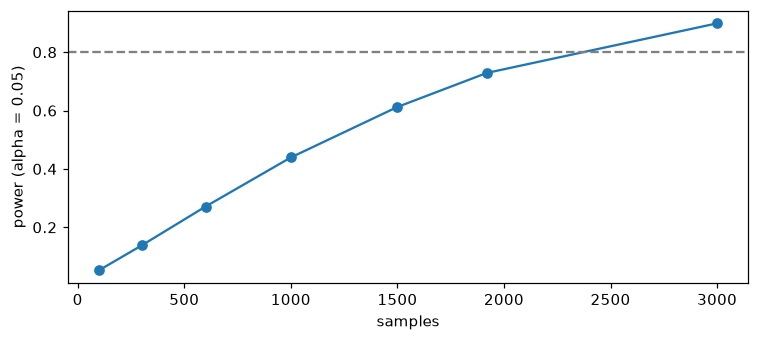

In [13]:
from functools import lru_cache

@lru_cache(maxsize=None)
def p_exact(b, c):
    return mcnemar(b, c)

pi_d, pi_b = d / n, only_a / d
print(f"pi_d = {pi_d:.3f}, pi_b = {pi_b:.3f}")

def power(n_samples, trials=20_000, alpha=0.05):
    ds = rng.binomial(n_samples, pi_d, size=trials)
    bs = rng.binomial(ds, pi_b)
    return np.mean([p_exact(int(b), int(dd - b)) < alpha for b, dd in zip(bs, ds)])

ns = [100, 300, 600, 1000, 1500, 1920, 3000]
pw = [power(m) for m in ns]
for m, w in zip(ns, pw):
    print(f"n = {m:>3}: power = {w:.2f}")
plt.plot(ns, pw, "o-"); plt.axhline(0.8, ls="--", c="gray")
plt.xlabel("samples"); plt.ylabel("power (alpha = 0.05)"); plt.tight_layout(); plt.show()

Với hiệu ứng cỡ này, lực ở 100 câu gần như bằng $\alpha$ — thí nghiệm gần như **không thể**
phát hiện ra nó; ở 300 câu, cứ bảy lần thì chỉ khoảng một lần phát hiện được. Kết quả "không
phân biệt được" ở 100 hay 300 câu là kết cục *có khả năng nhất*, không phải một sự cố. Ngay
cả 1.920 câu cũng chỉ cho lực khoảng 0,7; muốn đạt 80% (mức quy ước khi thiết kế thí nghiệm)
cần khoảng 2.300 câu — nhiều hơn cả tập validation.

Bài học có tên riêng: **thiếu bằng chứng không phải là bằng chứng về sự vắng mặt**
(absence of evidence is not evidence of absence). Quy trình đúng là ước lượng lực
**trước** khi chạy, từ một lần chạy thử, như vừa làm ở trên.

**Lưu ý — đừng tính lực từ chính kết quả vừa đo.** Ở đây $\pi_d, \pi_b$ lấy từ chính lần
chạy 1.920 câu, nên phép tính chỉ mang tính minh hoạ: "lực quan sát được" (observed power)
chỉ là một cách viết lại p-value, không thêm thông tin. Khi thiết kế thật, chúng đến từ một
lần chạy thử, hoặc tốt hơn, từ **hiệu ứng nhỏ nhất mà ta quan tâm** phát hiện. Dự án từng
ước lượng từ 300 câu đầu và dự đoán lực 0,96 cho 1.920 câu — 300 câu thì ước lượng $\pi_b$
quá nhiễu; chính ước lượng lực cũng có sai số.

## 7. Bootstrap: khoảng tin cậy khi không có công thức

Wilson cho khoảng tin cậy của một tỉ lệ. Nhưng ta còn muốn khoảng tin cậy cho **chênh
lệch** độ chính xác giữa hai cấu hình trên cùng câu hỏi, hay cho **trung vị tăng tốc**
1,92× — những đại lượng không có công thức gọn.

**Bootstrap** thay công thức bằng tính toán. Lập luận: phân phối lấy mẫu là thứ ta sẽ
thấy nếu rút mẫu mới từ tổng thể nhiều lần. Ta không có tổng thể, nhưng mẫu 300 câu là
bản xấp xỉ tốt nhất của nó. Vậy:

1. Rút **có hoàn lại** $n$ câu từ chính $n$ câu đã có (một câu có thể bị rút nhiều lần,
   câu khác không lần nào).
2. Tính lại đại lượng quan tâm trên mẫu mới đó.
3. Lặp lại $B$ lần (vài nghìn); phân vị 2,5% và 97,5% của $B$ giá trị là khoảng tin cậy
   95% — gọi là **khoảng phân vị** (percentile interval).

**Điều kiện áp dụng:** các câu phải được rút độc lập, và khi so hai cấu hình thì phải
**rút cả cặp** (giữ nguyên việc câu $i$ của A đi với câu $i$ của B) — nếu không sẽ
đánh mất đúng thông tin làm nên sức mạnh của thiết kế theo cặp.

Kiểm tra trước: với một tỉ lệ đơn, SE từ bootstrap phải gần SE từ công thức.

In [14]:
B = 10_000
idx = rng.integers(0, n, size=(B, n))                 # B resamples of n indices, with replacement
boot_acc = x_base[idx].mean(axis=1)
print(f"SE of accuracy: bootstrap {boot_acc.std():.4f} vs formula {se_formula:.4f}")

def paired_boot_ci(xa, xb, B=10_000):
    """95% percentile interval for mean(xb) - mean(xa), resampling pairs together."""
    ii = rng.integers(0, len(xa), size=(B, len(xa)))
    deltas = xb[ii].mean(axis=1) - xa[ii].mean(axis=1)
    return np.percentile(deltas, [2.5, 97.5])

lo, hi = paired_boot_ci(x_base, x_e768)
print(f"edge768 - baseline: {100*(x_e768.mean()-x_base.mean()):+.1f} pts, "
      f"95% CI [{100*lo:+.1f}, {100*hi:+.1f}]")

sp_idx = rng.integers(0, len(speedups), size=(B, len(speedups)))
sp_lo, sp_hi = np.percentile(np.median(speedups[sp_idx], axis=1), [2.5, 97.5])
print(f"median speedup {np.median(speedups):.2f}x, 95% CI [{sp_lo:.2f}, {sp_hi:.2f}]")

SE of accuracy: bootstrap 0.0114 vs formula 0.0113


edge768 - baseline: -2.2 pts, 95% CI [-3.9, -0.6]


median speedup 1.92x, 95% CI [1.91, 1.93]


Khoảng tin cậy cho chênh lệch **không chứa 0** — nhất quán với p = 0,011. Khoảng của
tăng tốc rất hẹp, đúng như dự đoán ở mục 5.1.

## 8. Độ lớn hiệu ứng khác ý nghĩa thống kê

Hai khái niệm này hay bị trộn lẫn:

| | Trả lời câu hỏi | Công cụ |
|---|---|---|
| **Độ lớn hiệu ứng** (effect size) | chênh lệch *bao nhiêu*? | hiệu số, kèm khoảng tin cậy |
| **Ý nghĩa thống kê** | chênh lệch có *phân biệt được* với may rủi? | p-value |

Khoảng tin cậy của hiệu số chứa **cả hai** thông tin: nó cho biết hiệu ứng lớn cỡ nào,
và nếu nó không chứa 0 thì hiệu ứng có ý nghĩa thống kê. Vì vậy nó đáng được báo cáo
hơn một p-value đứng riêng.

Áp dụng lên ba kết luận của dự án. Lần chạy nf4 và lần chạy bf16 là **hai lần chạy
riêng**, nhưng trên cùng 300 câu (cùng seed), nên vẫn ghép cặp được theo mã câu — đó
là việc `bench/compare_runs.py` làm.

In [15]:
def paired_arrays(run_a, cfg_a, run_b, cfg_b):
    a, b = per_sample(run_a, cfg_a), per_sample(run_b, cfg_b)
    ids = sorted(set(a) & set(b))
    return (np.array([a[s][0] for s in ids]), np.array([b[s][0] for s in ids]))

def report(name, xa, xb):
    oa = int(((xa == 1) & (xb == 0)).sum()); ob = int(((xa == 0) & (xb == 1)).sum())
    lo, hi = paired_boot_ci(xa, xb)
    print(f"{name:<34} n={len(xa)}  delta {100*(xb.mean()-xa.mean()):+5.1f} pts  "
          f"95% CI [{100*lo:+5.1f}, {100*hi:+5.1f}]  discordant {oa}+{ob}  p={mcnemar(oa, ob):.3f}")

nf4 = load("gate5_nf4.json")
prompt = load("gate6_prompt.json")
report("edge768 vs baseline (bf16)", x_base, x_e768)
report("nf4 vs bf16 (baseline config)", *paired_arrays(confirm, "baseline", nf4, "baseline"))
report("English vs Vietnamese instruction", *paired_arrays(prompt, "baseline", prompt, "prompten(prompt=en)"))

edge768 vs baseline (bf16)         n=1920  delta  -2.2 pts  95% CI [ -3.8,  -0.5]  discordant 150+108  p=0.011
nf4 vs bf16 (baseline config)      n=300  delta  -1.7 pts  95% CI [ -6.0,  +2.3]  discordant 23+18  p=0.533
English vs Vietnamese instruction  n=200  delta  +2.5 pts  95% CI [ -2.5,  +7.5]  discordant 10+15  p=0.424


Đọc từng dòng:

- **Cạnh 768**: khoảng tin cậy nằm hẳn dưới 0 nhưng sát 0 — hiệu ứng **có thật và nhỏ**,
  khoảng 1–4 điểm. Có ý nghĩa thống kê không có nghĩa là lớn; với tốc độ gần gấp đôi, đây là
  một đánh đổi mà nhiều hệ thống sẽ chấp nhận.
- **nf4**: điểm ước lượng −1,7 điểm, khoảng tin cậy từ khoảng −6 đến +2. Không phân biệt được
  với "không đổi" — nhưng hãy nhìn độ **rộng**: 300 câu không loại trừ được một mức mất tới
  khoảng 6 điểm. Cách nói đúng là *"không phát hiện được; nếu có thì dưới khoảng 6 điểm"*.
- **Ngôn ngữ chỉ dẫn**: tương tự, p = 0,42, khoảng tin cậy từ khoảng −2,5 đến +7,5 điểm —
  không phải "chắc chắn không ảnh hưởng".

**Chiều ngược lại — ý nghĩa thống kê mà không đáng kể.** Với đủ nhiều mẫu, chênh lệch
nhỏ đến đâu cũng thành "có ý nghĩa". Mô phỏng một chênh lệch thật chỉ 0,5 điểm:

Với hàng trăm nghìn cặp bất đồng, tổng nhị thức chính xác trở nên rất chậm (số nguyên
khổng lồ). May là định lý giới hạn trung tâm lại giúp: với $d$ lớn,
$b \sim \mathrm{Binomial}(d, \tfrac12)$ xấp xỉ chuẩn với trung bình $d/2$ và độ lệch
chuẩn $\sqrt d/2$, nên

$$z = \frac{b - d/2}{\sqrt d/2} = \frac{b - c}{\sqrt{b + c}}, \qquad \text{p} \approx 2\big(1-\Phi(|z|)\big)$$

— đây là **dạng xấp xỉ** của McNemar, dùng được khi $b + c$ lớn (vài chục trở lên).

In [16]:
def mcnemar_normal(b, c):
    z = (b - c) / math.sqrt(b + c)
    return 2 * (1 - phi(abs(z)))

print(f"check on the real data: exact {mcnemar(only_a, only_b):.4f} vs normal approx {mcnemar_normal(only_a, only_b):.4f}")
for m in [300, 3_000, 30_000, 300_000]:
    a = rng.random(m) < 0.650
    b = rng.random(m) < 0.645                          # true difference: 0.5 points
    p_ = mcnemar_normal(int((a & ~b).sum()), int((~a & b).sum()))
    print(f"n = {m:>7}: measured delta {100*(b.mean()-a.mean()):+.2f} pts, p = {p_:.2g}")

check on the real data: exact 0.0106 vs normal approx 0.0089
n =     300: measured delta -1.67 pts, p = 0.65
n =    3000: measured delta +0.03 pts, p = 0.98
n =   30000: measured delta -0.77 pts, p = 0.049
n =  300000: measured delta -0.71 pts, p = 8.8e-09


Dòng đầu cho thấy với 258 cặp bất đồng, xấp xỉ chuẩn cho p hơi nhỏ hơn giá trị chính xác
(0,0089 so với 0,0106) — lý do dự án dùng dạng chính xác, nhất là khi số cặp còn ít.

Với vài trăm nghìn mẫu, 0,5 điểm trở thành "có ý nghĩa thống kê cao" — nhưng không ai
thay đổi quyết định kỹ thuật vì 0,5 điểm. (Mô phỏng này sinh A và B độc lập nên có rất
nhiều cặp bất đồng; điều đó không đổi kết luận.) Ý nghĩa thống kê chỉ trả lời "có phân
biệt được không"; việc hiệu ứng có **đáng kể** không là câu hỏi kỹ thuật, trả lời bằng
độ lớn hiệu ứng.

## 9. Một lưu ý cuối: so sánh nhiều lần

Bảng các đòn bẩy trong README so 11 cấu hình với bản gốc. Nếu mỗi phép so có xác suất
báo động giả $\alpha = 0{,}05$ và các phép so độc lập, xác suất có **ít nhất một** báo
động giả trong $m$ phép so là:

$$1 - (1-\alpha)^m, \qquad m = 11:\; 1 - 0{,}95^{11} \approx 0{,}43$$

Cách sửa đơn giản nhất là **hiệu chỉnh Bonferroni**: dùng ngưỡng $\alpha/m$ cho từng phép
so. README dùng **Holm**, một biến thể luôn bác bỏ ít nhất bằng Bonferroni: sắp p-value tăng
dần, nhân p-value thứ $i$ với $(m - i + 1)$, rồi giữ cho dãy không giảm.

**Thăm dò khác khẳng định.** Lần quét 11 cấu hình là **thăm dò** — tìm xem đòn bẩy nào đáng
quan tâm — nên phải hiệu chỉnh. Lần chạy cạnh 768 trên cả 1.920 câu là **khẳng định**: một giả
thuyết duy nhất, chọn *trước* khi chạy, nên ngưỡng $\alpha = 0{,}05$ áp nguyên cho nó (p = 0,011).
Tách hai loại phép so này ra là cách giữ cho cả hai có nghĩa: nếu dùng dữ liệu thăm dò để
chọn giả thuyết rồi kiểm định trên *chính* dữ liệu đó, p-value không còn đúng nữa.

**Ký hiệu mới**
- $m$: số phép so sánh

## Tóm tắt

| Công cụ | Dùng khi | Con số trong dự án |
|---|---|---|
| Sai số chuẩn $\sqrt{p(1-p)/n}$ | ước lượng dao động của một tỉ lệ | ±1,1 điểm với 1.920 câu |
| Khoảng Wilson | khoảng tin cậy tỉ lệ, kể cả khi ít mẫu | rộng ~4,5 điểm (1.920 câu), ~28 điểm (40 câu) |
| McNemar chính xác | so hai cấu hình trên cùng câu hỏi | cạnh 768: 150 so với 108 cặp, p = 0,011 |
| Kiểm định dấu | so thời gian theo cặp | cạnh 768 nhanh hơn ở 1.919/1.920 câu |
| Lực kiểm định | chọn cỡ mẫu trước khi chạy | hiệu ứng 2 điểm: 300 câu lực ~0,14; cần ~2.300 cho 0,8 |
| Bootstrap theo cặp | khoảng tin cậy cho hiệu số, trung vị | tăng tốc 1,92× có khoảng rất hẹp |
| Độ lớn hiệu ứng | quyết định kỹ thuật | cạnh 768: có thật nhưng nhỏ; nf4: không phân biệt được |
| Thăm dò và khẳng định | nhiều phép so | quét 11 cấu hình: Holm; cạnh 768 trên toàn tập: một giả thuyết |

Notebook tiếp theo (01) dùng các công cụ này để phân tích các lỗi đo đạc đã gặp trong
dự án.